In [28]:
import matplotlib.pyplot as plt
from main_funcs import *
from pathlib import Path
import numpy as np

plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
})

In [29]:
base_dirs = {
    "Without": Path("data/Without EDM"),
    "With": Path("data/With EDM"),
    "Without New": Path("data/Without EDM NEW"),
    "With New": Path("data/With EDM NEW")
}

data_all = load_array_data(base_dirs)

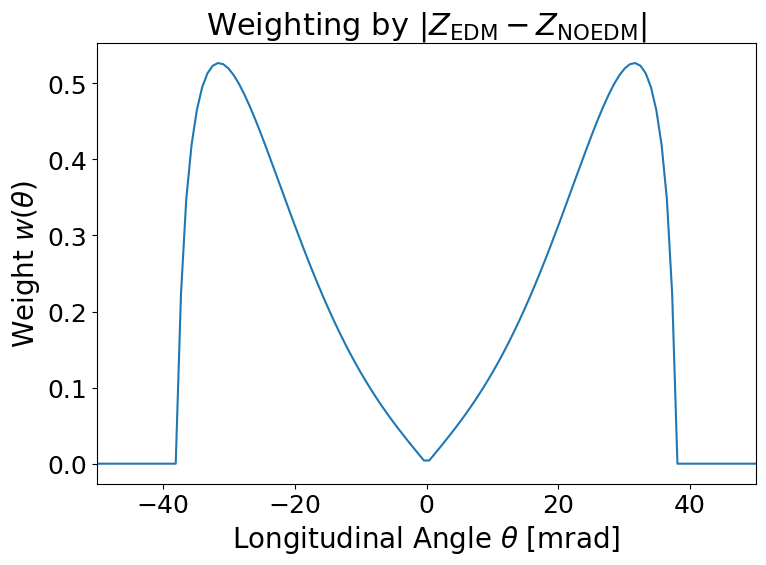

In [30]:
lambdas = data_all["With New"][7]["X"][0,:]
thetas = data_all["With New"][7]["Y"][:,0]

lambda_curr = 0.45
i_lam = np.argmin(np.abs(lambdas-lambda_curr))

Z_with = data_all["With New"][7]["Z"][:,i_lam]
Z_without = data_all["Without New"][7]["Z"][:,i_lam]
w_diff = np.abs(Z_with-Z_without)

fig = plt.figure(figsize=(8,6))
plt.plot(thetas,w_diff)
plt.xlim([-50,50])
plt.title(r"Weighting by |$Z_\mathrm{EDM}-Z_\mathrm{NO EDM}$|")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel(r"Weight $w(\theta)$")
plt.savefig("phd interview/w_diff.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

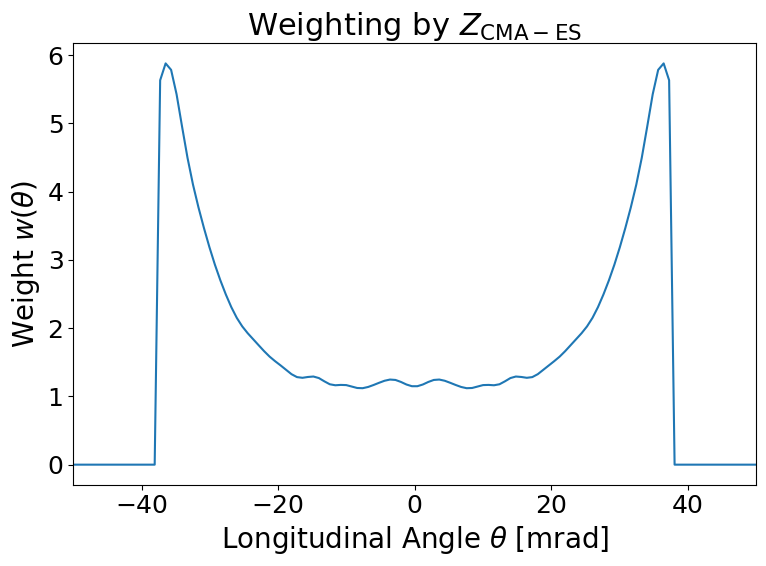

In [31]:
w_cma = np.load("C:/Users/JakeS/Documents/Masters Project/mphys-masters-project/Weight_Maps2/optimal_weight_lam=0.45_budget=2040.npz", allow_pickle=True)
w_cma = w_cma["weight"][:,i_lam]

fig = plt.figure(figsize=(8,6))
plt.plot(thetas,w_cma)
plt.xlim([-50,50])
plt.title(r"Weighting by $Z_\mathrm{CMA-ES}$")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel(r"Weight $w(\theta)$")
plt.savefig("phd interview/w_cma.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

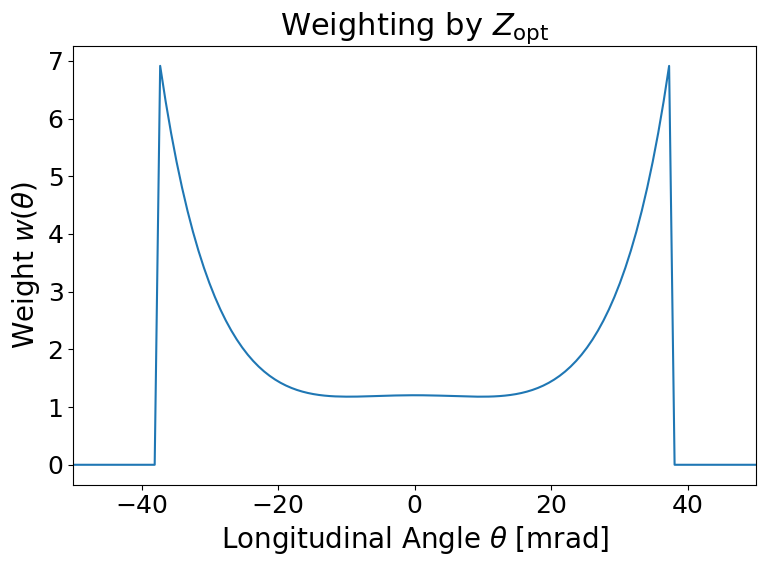

In [41]:
w0 = w_cma

num_sum = np.zeros_like(thetas, dtype=float)
den_sum = np.zeros_like(thetas, dtype=float)

for run_id, grids in data_all["With New"].items():
    Zcol = grids["Z"][:, i_lam]
    p = 1e5 * Zcol * 1e-3

    A = np.sum(p * w0)
    B = np.sum(p * w0 * thetas)
    C = np.sum(p * w0 * thetas**2)
    D = np.sum(p * w0**2)

    y  = B / A
    s2 = C / A - (B / A)**2
    sigma2 = s2 * D / A**2

    Delta = thetas - y
    a = Delta - (y * Delta**2)/(2 * s2) + 1.5 * y

    b = (y * A) / D

    weight = (y * p) / sigma2
    num_sum += weight * a
    den_sum += weight * b
    
eps = 1e-30
mask = den_sum > eps

w_opt = np.zeros_like(thetas, dtype=float)
w_opt[mask] = num_sum[mask] / den_sum[mask]

w_opt = np.maximum(0.0, w_opt)

fig = plt.figure(figsize=(8,6))
plt.plot(thetas,w_opt)
plt.xlim([-50,50])
plt.title(r"Weighting by $Z_\mathrm{opt}$")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel(r"Weight $w(\theta)$")
plt.savefig("phd interview/w_opt.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

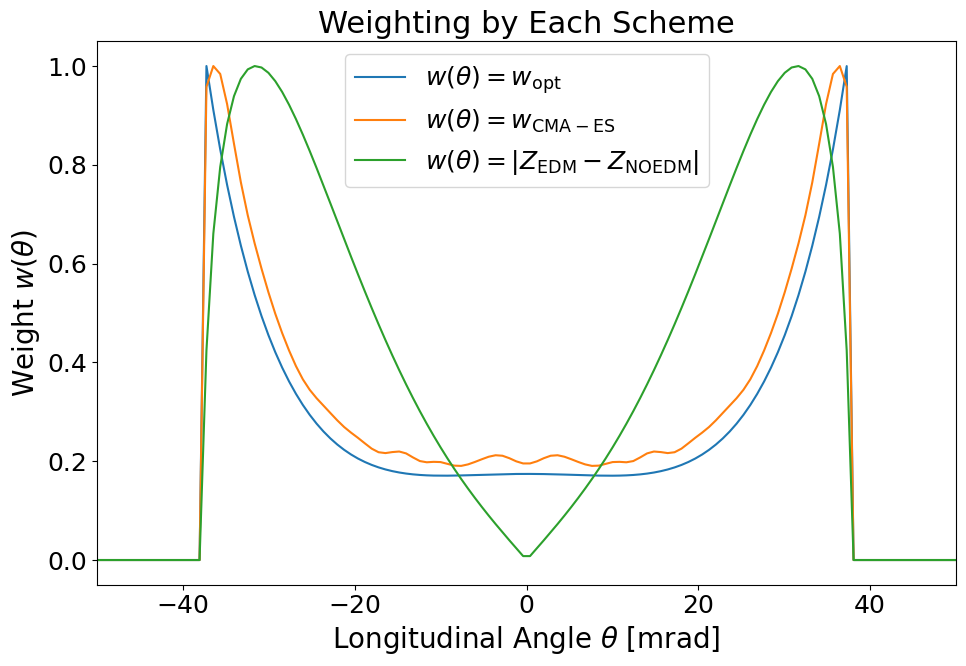

In [50]:
fig = plt.figure(figsize=(10,7))
plt.plot(thetas,w_opt/np.nanmax(w_opt), label=r"$w(\theta) = w_\mathrm{opt}$")
plt.plot(thetas,w_cma/np.nanmax(w_cma), label=r"$w(\theta) = w_\mathrm{CMA-ES}$")
plt.plot(thetas,w_diff/np.nanmax(w_diff), label=r"$w(\theta) = |Z_\mathrm{EDM}-Z_\mathrm{NO EDM}$|")

plt.xlim([-50,50])
plt.title(r"Weighting by Each Scheme")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel(r"Weight $w(\theta)$")
plt.savefig("phd interview/w_all.png", bbox_inches="tight")
plt.tight_layout()
plt.legend()
plt.show()

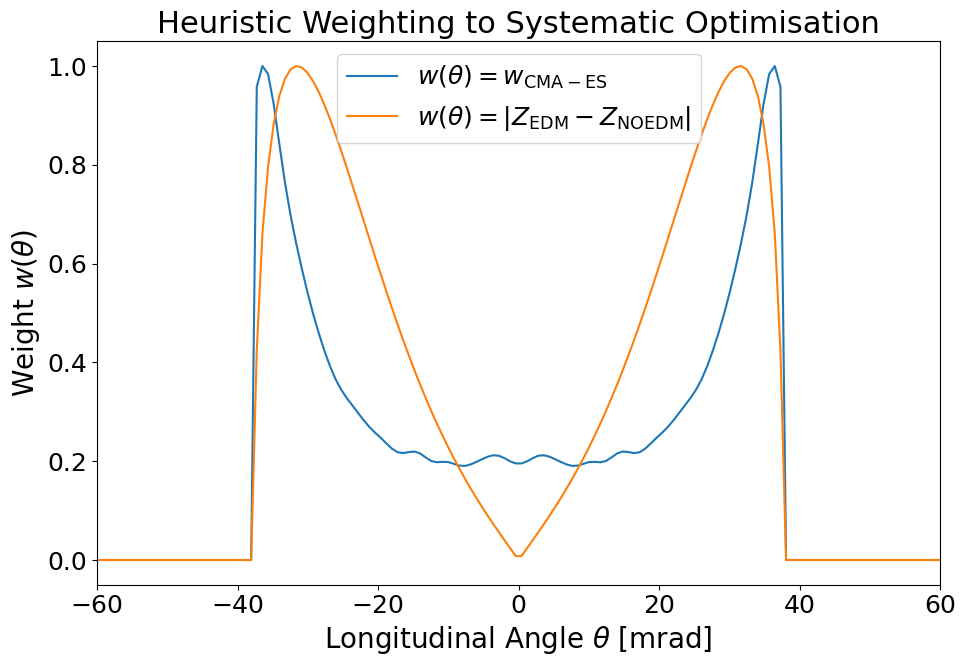

In [49]:
fig = plt.figure(figsize=(10,7))
plt.plot(thetas,w_cma/np.nanmax(w_cma), label=r"$w(\theta) = w_\mathrm{CMA-ES}$")
plt.plot(thetas,w_diff/np.nanmax(w_diff), label=r"$w(\theta) = |Z_\mathrm{EDM}-Z_\mathrm{NO EDM}$|")

plt.xlim([-60,60])
plt.title(r"Heuristic Weighting to Systematic Optimisation")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel(r"Weight $w(\theta)$")
plt.legend()
plt.tight_layout()
plt.savefig("phd interview/w_heuristic.png", bbox_inches="tight")
plt.show()

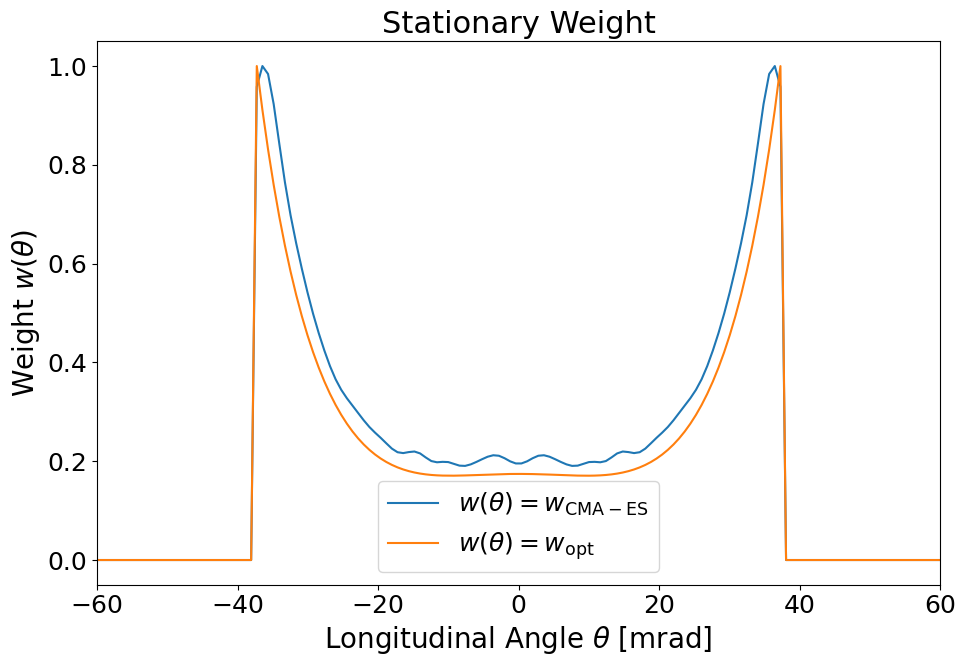

In [48]:
fig = plt.figure(figsize=(10,7))
plt.plot(thetas,w_cma/np.nanmax(w_cma), label=r"$w(\theta) = w_\mathrm{CMA-ES}$")
plt.plot(thetas,w_opt/np.nanmax(w_opt), label=r"$w(\theta) = w_\mathrm{opt}$")

plt.xlim([-60,60])
plt.title(r"Stationary Weight")
plt.xlabel(r"Longitudinal Angle $\theta$ [mrad]")
plt.ylabel(r"Weight $w(\theta)$")
plt.legend()
plt.tight_layout()
plt.savefig("phd interview/w_stationarity.png", bbox_inches="tight")
plt.show()